# EDA: Detección de Fraude en Pagos Digitales

<big>**Integrantes**<big>

Estefania Cervera\
Andres Felipe Orozco Roa\
Cristina Garces

## Objetivo:

Analizar y comprender el conjunto de datos de transacciones digitales para identificar patrones de comportamiento, anomalías y relaciones multivariadas que diferencien las transacciones genuinas de las fraudulentas. Este análisis servirá para limpiar los datos, generar nuevas características relevantes (Feature Engineering) y sentar las bases estratégicas para el entrenamiento de modelos predictivos de Machine Learning eficaces.

## Diccionario de Datos Dataset

A continuacion detallaremos las columnas que la Data posee para realizar nuestro analisis exploratorio.

**- Transaction_id:** Identificador único de cada transacción (Alfanumérico).

**- User_id:** Identificador único del usuario que realiza la operación.

**- Transaction_amount:** Monto de la transacción actual en la moneda local.

**- Transaction_type:** Tipo de movimiento realizado (Transferencia, Pago, Retiro).

**- Payment_mode:** Método de pago utilizado (Tarjeta, Billetera Digital, UPI, NetBanking).

**- Device_type:** Sistema operativo o plataforma desde donde se originó la transacción (Android, iOS, Web).

**- Device_location:** Ciudad o región desde donde se conectó el dispositivo.

**- Account_age_days:** Antigüedad de la cuenta del usuario en días.

**- Transaction_hour:** Hora del día en formato 24h (0 - 23) en la que ocurrió la transacción.

**- Previous_failed_attempts:** Cantidad de transacciones fallidas previas registradas para ese usuario.

**- Avg_transaction_amount:** Monto promedio histórico de transacciones realizadas por el usuario.

**- Is_international:** Variable binaria (1 = Sí, 0 = No) que indica si la transacción cruzó fronteras internacionales.

**- Ip_risk_score:** Puntaje de riesgo (0.0 a 1.0) asignado a la dirección IP desde donde se conectó el usuario.

**- Login_attempts_last_24h:** Número de intentos de inicio de sesión en la cuenta durante las últimas 24 horas.

**- Fraud_label:** Variable Objetivo. (1 = Transacción Fraudulenta, 0 = Transacción Genuina).

# 1. Configuracion de la Data

Como primer paso procederemos a la Importación de librerías (pandas, matplotlib, seaborn y numpy) , cargaremos el dataset y realizaremos una visualizacion parcial del mismo para confirmar que se realizao de manera correcta , para dar comienzo a nuestros analisis.

In [3]:
#Activemos el ambiente  en cmd .venv\Scripts\activate
#Importamos las librerías para usar en el EDA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
#Cargamos el dataset en csv que se encuentra en la carpeta
df= pd.read_csv("Digital_Payment_Fraud_Detection_Dataset.csv",sep=";",header="infer")

print('Archivo Pagos Cargado Exitosamente')

#Previsualizamos la información para ver que columnas tiene y que información puede estar en cada columna
df.head(3)

Archivo Pagos Cargado Exitosamente


,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0


# 2. Descripción del Dataset

A traves de  los metodos de descripcion de python y sus librerias validaremos la estructura que la data posee, haciendo revision de las dimensiones, tipos de datos y las medidas estadisticas basicas tanto para las variables numericas como las variables categoricas.

Inicialmente tomaremos como referencia una porcion de la data de manera aleatoria para tener conocimiento de los datos que esta nos esta entregando la dataset dentro del analisis exploratorio , por lo cual realizaremos mediante el metodo Sample  con el parametro random_state para no variar dicha porcion aleatoria para efectos del ejercicio.

In [5]:
df.sample(n=10, random_state=10)

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
4984,T4985,U7989,27555.49,Withdrawal,Card,Web,Bangalore,900,22,1,7270.27,0,0.917,1,0
1852,T1853,U8878,43075.43,Payment,UPI,Web,Chennai,515,17,0,15360.09,0,0.995,9,0
66,T67,U9847,7089.17,Transfer,Card,Android,Hyderabad,1800,22,4,24550.03,0,0.585,9,0
216,T217,U6936,16303.71,Withdrawal,Card,Android,Delhi,745,1,4,12963.44,0,0.187,8,0
5911,T5912,U6902,46332.94,Withdrawal,UPI,Web,Bangalore,405,6,0,18304.86,0,0.017,4,0
5526,T5527,U5090,31966.20,Transfer,UPI,iOS,Delhi,875,8,0,6241.30,0,0.798,3,0
191,T192,U6183,44865.93,Transfer,Wallet,Android,Delhi,1038,1,4,4224.42,0,0.556,8,0
5610,T5611,U3713,3894.61,Withdrawal,Wallet,iOS,Mumbai,1816,21,3,14820.23,0,0.238,1,0
7421,T7422,U3944,34519.26,Withdrawal,Card,Android,Chennai,1527,20,3,17741.98,0,0.591,8,1
7155,T7156,U4289,41146.87,Transfer,Wallet,iOS,Hyderabad,1872,7,0,16820.48,0,0.265,5,0


Despues de la validacion de la porcion de la data utilizaremos el Metodo Info para saber la descripcion de las data  en cuanto numero de columnas, numero filas o registros , valores nulos por columna y tipo de datos por columna.

Tambien realizaremos un dataframe para visulaizar los valores unicos por columna.

In [6]:
print("\n🔍 Paso 2: Descripción del dataset")
print("-" * 40)
# 1. Número de filas y columnas
filas, columnas = df.shape

# 2. Información de cada columna
df.info()

# 3. Diccionario simple de datos
info_columnas = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Valores Nulos': df.isnull().sum(),
    'Valores Únicos': df.nunique()
})
display(info_columnas)


🔍 Paso 2: Descripción del dataset
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_id            7500 non-null   str    
 1   user_id                   7500 non-null   str    
 2   transaction_amount        7500 non-null   float64
 3   transaction_type          7500 non-null   str    
 4   payment_mode              7500 non-null   str    
 5   device_type               7500 non-null   str    
 6   device_location           7500 non-null   str    
 7   account_age_days          7500 non-null   int64  
 8   transaction_hour          7500 non-null   int64  
 9   previous_failed_attempts  7500 non-null   int64  
 10  avg_transaction_amount    7500 non-null   float64
 11  is_international          7500 non-null   int64  
 12  ip_risk_score             7500 non-null   float64
 13

,Tipo de Dato,Valores Nulos,Valores Únicos
transaction_id,str,0,7500
user_id,str,0,5106
transaction_amount,float64,0,7499
transaction_type,str,0,3
payment_mode,str,0,4
device_type,str,0,3
device_location,str,0,5
account_age_days,int64,0,1943
transaction_hour,int64,0,24
previous_failed_attempts,int64,0,5


Posteriomente de validar que el Dataset posee 9 columnas numericas y 6 categoricas para un total 15 columna y 7500 filas de registros ,encontramos que no hay valores nulos dentro de nuestra data y que 5106 usuarios unicos ,proseguiremos a realizar una revision de las medidas estadisticas basicas para las columnas numericas, mediante el metodo de Python describe

In [7]:
#Revisemos estadística basica para cada columna Numericas
df.describe()

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,24813.534161,1006.904533,11.435867,2.013600,15129.061027,0.100667,0.505026,4.995067,0.065200
std,14434.742371,575.632925,6.950899,1.421578,8597.760720,0.300907,0.289647,2.593879,0.246895
min,50.580000,10.000000,0.000000,0.000000,102.790000,0.000000,0.000000,1.000000,0.000000
25%,12272.785000,502.750000,5.000000,1.000000,7725.842500,0.000000,0.257000,3.000000,0.000000
50%,24715.550000,1018.000000,11.000000,2.000000,15074.810000,0.000000,0.502000,5.000000,0.000000
75%,37288.375000,1505.000000,18.000000,3.000000,22573.062500,0.000000,0.759000,7.000000,0.000000
max,49985.900000,1999.000000,23.000000,4.000000,29994.290000,1.000000,1.000000,9.000000,1.000000


conforme la aplicacion de este analisis podemos empezar a ver que columnas podrian ser de nuestro interes para el analisis exploratorio en las posibles hiportesis a plantear, y continuaremos con el describe pero a las columnas de caracter string o Object.

In [8]:
#Revisemos Estadisticas Basicas para las columnas String o objetc
df.describe(include="object")

C:\Users\ssaforozco\AppData\Local\Temp\ipykernel_52396\1657064915.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,transaction_id,user_id,transaction_type,payment_mode,device_type,device_location
count,7500,7500,7500,7500,7500,7500
unique,7500,5106,3,4,3,5
top,T1,U1247,Payment,Card,Web,Hyderabad
freq,1,6,2511,1912,2537,1614


Al finalizar el analisis que describe la data podemos concluir que la variable objetivo dentro de nuestro analisis es fraud_label en el cual basar los analisis posteriores de caranter univariado , bivariado y multivariado que conforme a los indicios evidenciados en los anterirores analisis nos brinden patrones para lograr nuestro objetivo.

# 3.Análisis Univariado, Bivariado y Multivariado:

Conforme a la conclusion anterior y definido la variable objetivo Fraud_label vamos a realizar el discribe pero solo a los registrso que cumple criterio de fraude, por lo cual realizamos un dataframe y aplicamos  el metodo describe.

In [9]:
# Revisemos la estadistica basica sólo para lo que este marcado como fraude
df_fraude = df[df['fraud_label'] == 1]
df_fraude.describe()

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
count,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.0
mean,24256.210879,1071.456033,11.568507,2.096115,15310.463313,0.083845,0.508689,5.155419,1.0
std,14289.574936,566.853237,6.873261,1.418902,8702.706731,0.277438,0.301381,2.557610,0.0
min,245.720000,10.000000,0.000000,0.000000,392.350000,0.000000,0.000000,1.000000,1.0
25%,11770.370000,564.000000,6.000000,1.000000,7576.580000,0.000000,0.245000,3.000000,1.0
50%,24260.580000,1108.000000,12.000000,2.000000,15421.840000,0.000000,0.485000,5.000000,1.0
75%,35936.770000,1566.000000,18.000000,3.000000,22738.260000,0.000000,0.790000,7.000000,1.0
max,49985.900000,1996.000000,23.000000,4.000000,29826.310000,1.000000,0.995000,9.000000,1.0


Despues de este Describe podemos ver que hay 489 Registros marcados como fraudulentos con respecto a los 7500 registros totales y se realiza una descripcion estadistica de las variables numericas del Dataset tenien como referencia columnas como los  montos las horas e intentos fallido  de las transaciones. 

Tambien lo aplicaremos el describe a las variables categoricas con el dataframe previamente creado.

In [10]:
# Revisemos la estadistica basica sólo para lo que este marcado como fraude para variables categoricas
df_fraude = df[df['fraud_label'] == 1]
df_fraude.describe(include="object")

C:\Users\ssaforozco\AppData\Local\Temp\ipykernel_52396\2568968651.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_fraude.describe(include="object")


,transaction_id,user_id,transaction_type,payment_mode,device_type,device_location
count,489,489,489,489,489,489
unique,489,482,3,4,3,5
top,T7,U5701,Withdrawal,Card,Android,Hyderabad
freq,1,2,170,135,172,115


Concluido el analisis vemos que las transaciones fraudulentas en correlacion a toda la problacion de la data no difieren mucho en cuanto los valores medios de montos 24813 y 24256 ,ni en cuanto a las hora promedio totales 11.435 a las de los fraudes 11.568 , lo que si vemos es que por tipo de transacion del total de la los registro tiene como top que se realizan con Pago por tarjeta en la web mientras que las fraudulentas aplicaron desde Retiro dede tarjetas con dispositivos android, continuaremos el analisis con una grafica que nos de la proporcion en participacion de transaciones verdadera vs fraudulentas.

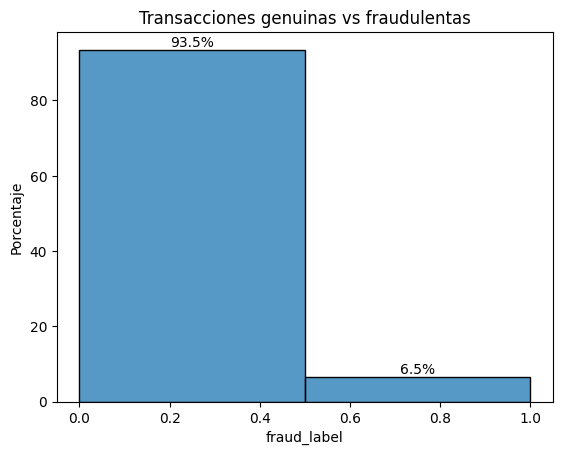

In [36]:
#Veamos que porcentaje de transacciones son reales vs fraudulentas
plt.title('Transacciones genuinas vs fraudulentas')
ax = sns.histplot(df['fraud_label'], bins=2, stat="percent")

# Agregamos el porcentaje a cada barra
for p in ax.patches:
    porcentaje = p.get_height()
    ax.annotate(f'{porcentaje:.1f}%', 
                (p.get_x() + p.get_width() / 2, porcentaje),
                ha='center', va='bottom')

plt.ylabel("Porcentaje")
plt.show()

Se puede ver que en el analisis de la grafica anterior que hay un desbalance en la variable objetivo, en una proporcion 6.5% de registros marcados como fraudulentos en relacion del 100% del Dataset.

Despues de los analisis anterior y conforme a las conclusiones e indicios nos plantemos Las siguiente preguntas en donde exploraremos la variable objetivo como se comporta con otras.

## Exploramos las variables a detalle


### A. ¿La hora del día en la que se hace la transacción, tiene relación con la marcación de fraude?

Conforme a la pregunta realizaremos un histograma que valide cantidad de transaciones vs hora del dia  y generarmos una grafica de densidad donde se compare dichos datos entre transaciones correcta vs fraudulenteas haciendo uso de librerias como seaborn y matplotlib.


🔍  Histograma
----------------------------------------
fraud_label
0    0.9348
1    0.0652
Name: proportion, dtype: float64


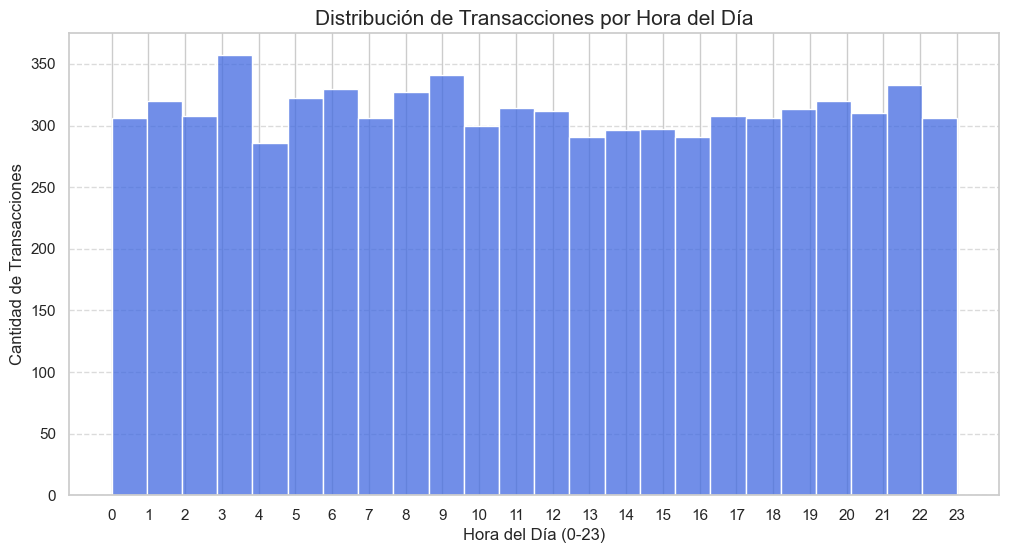


🔍  Grafico Densidad
----------------------------------------


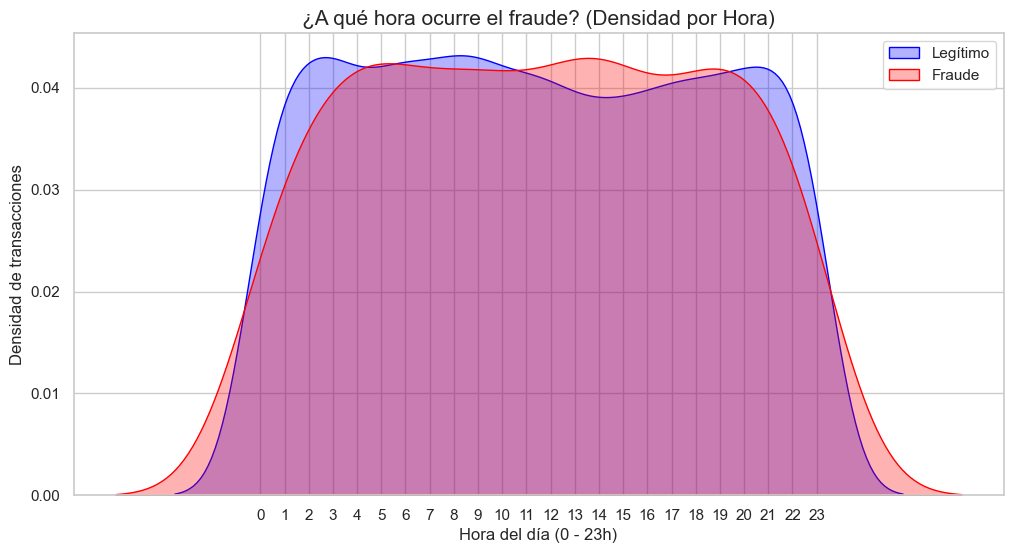

In [60]:

print("\n🔍  Histograma")
print("-" * 40)

# Revisamos las horas en las que hay datos de transacciones, y creamos histograma para ver como se distribuyen las transacciones
df['transaction_hour'].value_counts().sort_index()

print(df['fraud_label'].value_counts(normalize=True))


plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='transaction_hour', bins=24, kde=False, color='royalblue')
plt.title('Distribución de Transacciones por Hora del Día', fontsize=15)
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Cantidad de Transacciones')
plt.xticks(range(0, 24)) # Para que aparezcan todos los números del 0 al 23
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# 1. Configuramos el estilo

print("\n🔍  Grafico Densidad")
print("-" * 40)
sns.set_theme(style="whitegrid")

# 2. Creamos el gráfico de densidad para ver el comportamiento
plt.figure(figsize=(12, 6))

# Graficamos la distribución de la hora separando por fraude
sns.kdeplot(data=df[df['fraud_label'] == 0], x='transaction_hour', 
            label='Legítimo', fill=True, color='blue', alpha=0.3)
sns.kdeplot(data=df[df['fraud_label'] == 1], x='transaction_hour', 
            label='Fraude', fill=True, color='red', alpha=0.3)

# 3. Personalización del gráfico
plt.title('¿A qué hora ocurre el fraude? (Densidad por Hora)', fontsize=15)
plt.xlabel('Hora del día (0 - 23h)')
plt.ylabel('Densidad de transacciones')
plt.xticks(range(0, 24))
plt.legend()
plt.show()





#### Conclusion:
La hora del día no se ve relacionada con el fraude, las transacciones fraudulentas estan distribuidas en todos los horarios sin ver un patrón claro por fuera del comun de las transaciones,sin embargo se puede ver en el primer grafico que el tope de transaciones la estan realizando en horario de 3 a 4 de la mañana no siendo hora muy comun , pero al ver el grafico de densidad vemos que donde las transaccione fraudulentas superar a las verdaderas esta dentro del rango de las 12 am a las 7 de la noche , sin ser significativo dicho patron.

### B. ¿Cómo se distribuye el monto de las transacciones?


Queremos ver  con esta pregunta si la mayoría de las compras son pequeñas o grande vs la frecuencia de estas , y  si esto genera un patron en las transaciones fraudulentas, por lo cual realizaremos dos gradicas mostrando el total de transaciones con una linea promedio del monto y otra con la grafica solo con datos de transaciones fraudulentas.

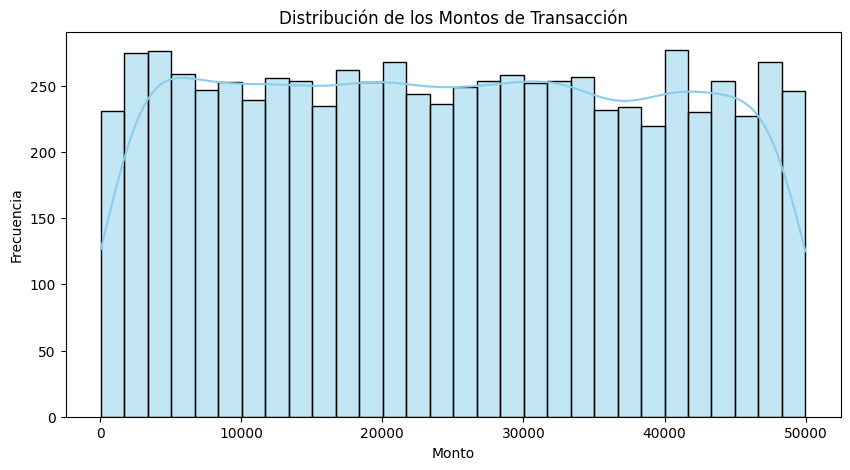

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['transaction_amount'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de los Montos de Transacción')
plt.xlabel('Monto')
plt.ylabel('Frecuencia')
plt.show()

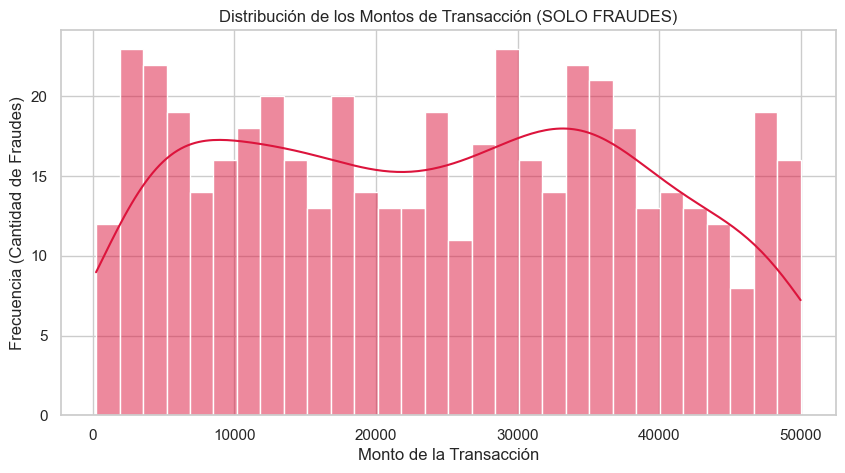

In [73]:
# Creamos un subconjunto de datos SOLO con los fraudes
df_fraude = df[df['fraud_label'] == 1]

# Generamos el gráfico
plt.figure(figsize=(10, 5))
sns.histplot(df_fraude['transaction_amount'], bins=30, kde=True, color='crimson')
plt.title('Distribución de los Montos de Transacción (SOLO FRAUDES)')
plt.xlabel('Monto de la Transacción')
plt.ylabel('Frecuencia (Cantidad de Fraudes)')
plt.show()

#### Conclusion
Analizamos que el monto de las transacciones tiene una distribución pareja y no se observa un valor o rango de valores con frecuencias mas altas que el resto,  en ambos graficos gráfico y las estadísticas nos muestran que los montos fraudulentos están distribuidos a lo largo de todo el espectro. Existen fraudes desde los $245 hasta rozar los $50,000 adicional que los valores fraudes estan encubiertos entra registros verdaderos.

### C. ¿Como se comporta  la distribución de los score de riesgo en las transacciones ?


Queremos analizar el comprotamiento del Score de riesgo conforme a las transacciones verdaderas vs las fraudulentas, por lo cual graficaremos generando un groupby  mediante Boxplot que nos permitaver dicha comparativa.

Riesgo de IP promedio:
fraud_label
0    0.504771
1    0.508689
Name: ip_risk_score, dtype: float64


C:\Users\ssaforozco\AppData\Local\Temp\ipykernel_6032\2646106059.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fraud_label', y='ip_risk_score', data=df, palette='Oranges')


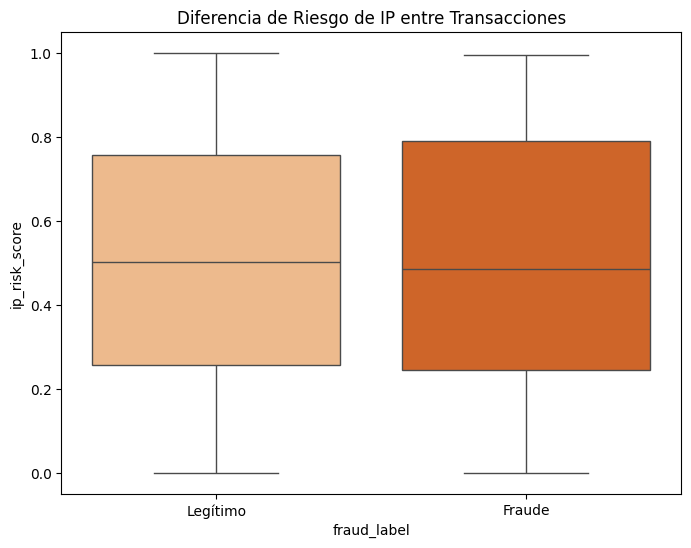

In [48]:
# Comparamos el riesgo promedio de IP entre transacciones normales y fraudes
promedio_riesgo = df.groupby('fraud_label')['ip_risk_score'].mean()
print("Riesgo de IP promedio:")
print(promedio_riesgo)

# Visualización de Boxplot para ver la diferencia clara
plt.figure(figsize=(8, 6))
sns.boxplot(x='fraud_label', y='ip_risk_score', data=df, palette='Oranges')
plt.title('Diferencia de Riesgo de IP entre Transacciones')
plt.xticks([0, 1], ['Legítimo', 'Fraude'])
plt.show()

#### Conclusion
Al observar los promedios numéricos, vemos que las transacciones legítimas tienen un riesgo de IP promedio de 0.504, mientras que las fraudulentas tienen un promedio de 0.508. Son valores prácticamente idénticos. por sí sola, es inútil para predecir el fraude. No podemos establecer una regla simple que diga "Si el riesgo de IP es mayor a 0.8, entonces es fraude", porque hay muchísimas transacciones legítimas con riesgo alto y muchos fraudes realizados desde IPs con riesgo bajo.

### D.¿Como se comporta  la distribucion segun el tipo y medio de las transaciones ?

Validaremos el comportamiento a travez del porcentaje a nivel del tipo y medio de transaccion en un comparativo de transaciones reales vs fraudulentas para evidenciar si hay patrones que nos indiquen el fraude, realizaremos dos graficas de barras por tipo de pago y medio de las transacciones y un dataframe con el porcentaje de las transacciones fraudulentas.

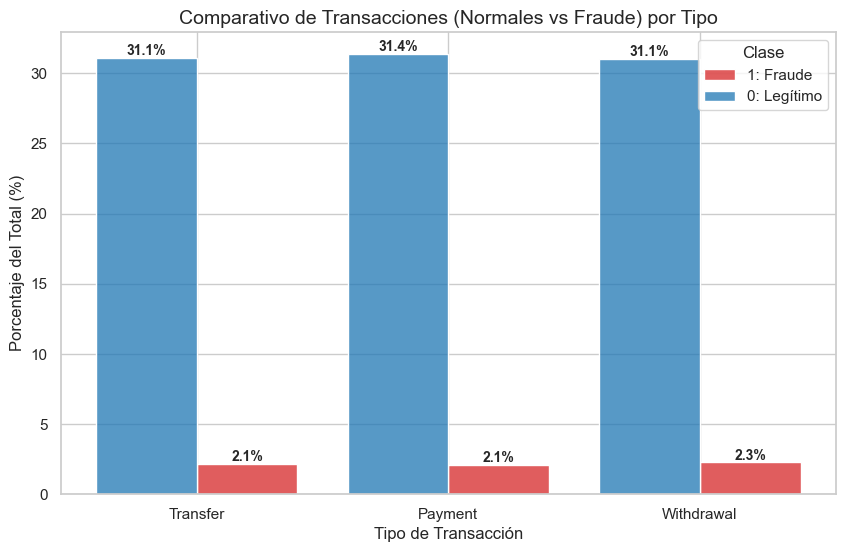

In [80]:

# 1. Generar el gráfico
plt.figure(figsize=(10, 6))
plt.title('Comparativo de Transacciones (Normales vs Fraude) por Tipo', fontsize=14)

# OJO: Aquí usamos 'df_grafico' en lugar de 'df'
ax = sns.histplot(
    data=df, 
    x='transaction_type', 
    hue='fraud_label', 
    stat="percent", 
    multiple="dodge", 
    shrink=0.8,
    palette=['#1f77b4', '#d62728'] # Azul para Legítimo, Rojo para Fraude
)

# 2. Ciclo for para añadir los porcentajes encima de cada barra
for p in ax.patches:
    porcentaje = p.get_height()
    # Solo anotamos si la barra tiene altura mayor a 0
    if porcentaje > 0:
        ax.annotate(f'{porcentaje:.1f}%', 
                    (p.get_x() + p.get_width() / 2., porcentaje),
                    ha='center', 
                    va='bottom',
                    fontsize=10,
                    fontweight='bold')

plt.xlabel('Tipo de Transacción', fontsize=12)
plt.ylabel('Porcentaje del Total (%)', fontsize=12)

# Ajustar la leyenda
plt.legend(title='Clase', labels=['1: Fraude', '0: Legítimo'])

plt.show()

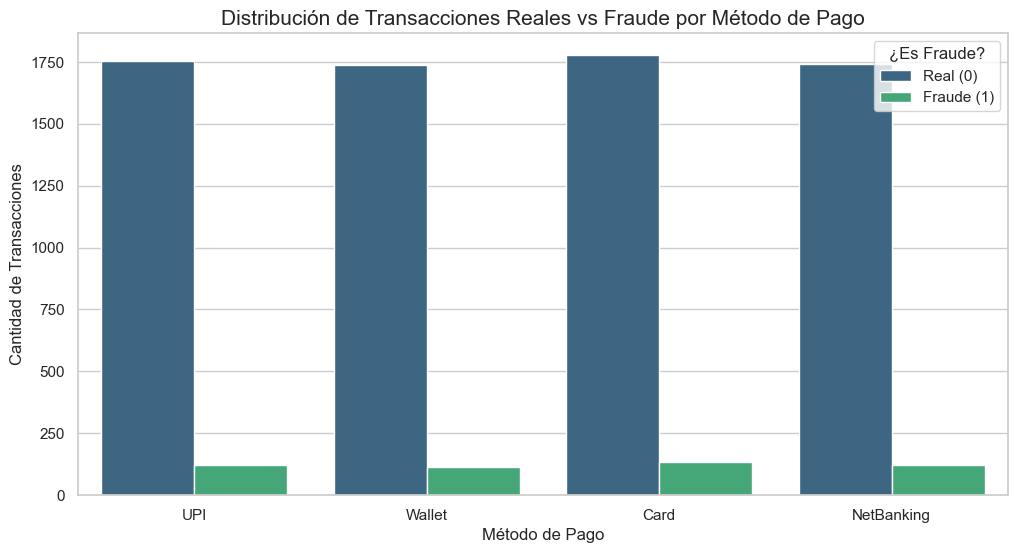

In [75]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(data=df, x='payment_mode', hue='fraud_label', palette='viridis')

plt.title('Distribución de Transacciones Reales vs Fraude por Método de Pago', fontsize=15)
plt.xlabel('Método de Pago', fontsize=12)
plt.ylabel('Cantidad de Transacciones', fontsize=12)
plt.legend(title='¿Es Fraude?', labels=['Real (0)', 'Fraude (1)'])

plt.show()

In [21]:
# 1. Calculamos el porcentaje de fraude por cada tipo de pago
tabla_fraude = df.groupby('payment_mode')['fraud_label'].mean() * 100

tabla_fraude = tabla_fraude.reset_index()

# 2. Renombramos las columnas para que sean claras
tabla_fraude.columns = ['Método de Pago', '% de Fraude']

# 3. Ordenamos de mayor a menor riesgo
tabla_fraude = tabla_fraude.sort_values(by='% de Fraude', ascending=False)

# 4. Mostramos la tabla con un estilo limpio
print("--- Porcentaje de Fraude por Método de Pago ---")
display(tabla_fraude)

--- Porcentaje de Fraude por Método de Pago ---


,Método de Pago,% de Fraude
0,Card,7.060669
1,NetBanking,6.444683
2,UPI,6.403415
3,Wallet,6.155508


#### Conclusion
La cantidad de transacciones por tipo de transaccion  en el volumen general de operaciones, la gran mayoría de todas las transacciones son "Pagos" (Payments) y "Transferencias" (Transfers). Sin embargo, la proporción de fraude (las barras rojas) se distribuye de manera muy similar y paralela entre los tres tipos de transacciones (Payment, Transfer y Withdrawal) destacando minimamente los retiros en mayor porcentaje algo que en los analisis anterior no habiamos visualizado y  en cuanto al medio de pago no tienen una concentración de fraude en algun item puntual, sin embargo el porcentaje más alto de fraudes está en tarjeta de crédito y el más seguro es wallet si ser un dato que destaque totalmente de los otros metodos.

### E. ¿ La disitribuccion geografica del Dataset tiene alguna incidencia el la generacion de fraudes y como se comporta?

Para realizar el analisis de esta pregunta ,realizaremos incialmente uso del metodo unique para ver las ciudades existentes en la data y  realizaremos un conteo de su distribucion entre nacional e internacional , posteriomente crearemos un dataframe el cual nos muestre el porcentaje de participacion por ciudad de registros fraudulentos que se completmente con una grafica  que marque la media de registros globales con fraude , tambien haremos una grafica de torta con la participacion de transaciones nacionales e internacionales  y por ultimo un dataframe y grafica  revisando como se comporta el riesgo en relacion con la localizacion.

In [22]:
# 1. Ver qué valores únicos hay en la ubicación
print("--- Ciudades/Ubicaciones en el dataset ---")
print(df['device_location'].unique())

# 2. Analizar la variable 'is_international'
print("\n--- Conteo de transacciones internacionales ---")
print(df['is_international'].value_counts())

--- Ciudades/Ubicaciones en el dataset ---
['Hyderabad' 'Chennai' 'Delhi' 'Mumbai' 'Bangalore']

--- Conteo de transacciones internacionales ---
is_international
0    6745
1     755
Name: count, dtype: int64


--- Ranking de Riesgo por Ciudad ---


,Ciudad,% de Fraude
0,Mumbai,7.308743
1,Hyderabad,7.125155
2,Chennai,6.198910
3,Bangalore,6.126482
4,Delhi,5.779944


C:\Users\USER\AppData\Local\Temp\ipykernel_17420\4213226323.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraude_ciudad, x='Ciudad', y='% de Fraude', palette='magma')


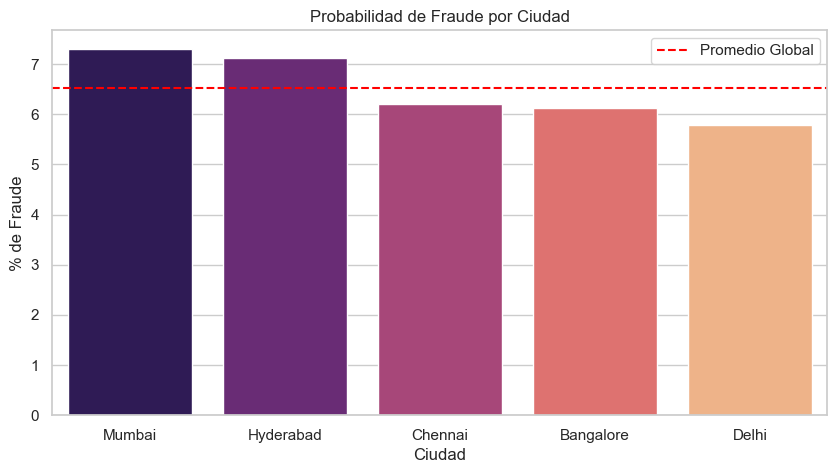

In [23]:
# Calcular el % de fraude por ciudad
fraude_ciudad = df.groupby('device_location')['fraud_label'].mean() * 100
fraude_ciudad = fraude_ciudad.sort_values(ascending=False).reset_index()
fraude_ciudad.columns = ['Ciudad', '% de Fraude']

print("--- Ranking de Riesgo por Ciudad ---")
display(fraude_ciudad)

# Gráfico de barras para comparar
plt.figure(figsize=(10, 5))
sns.barplot(data=fraude_ciudad, x='Ciudad', y='% de Fraude', palette='magma')
plt.title('Probabilidad de Fraude por Ciudad')
plt.axhline(df['fraud_label'].mean()*100, color='red', linestyle='--', label='Promedio Global')
plt.legend()
plt.show()

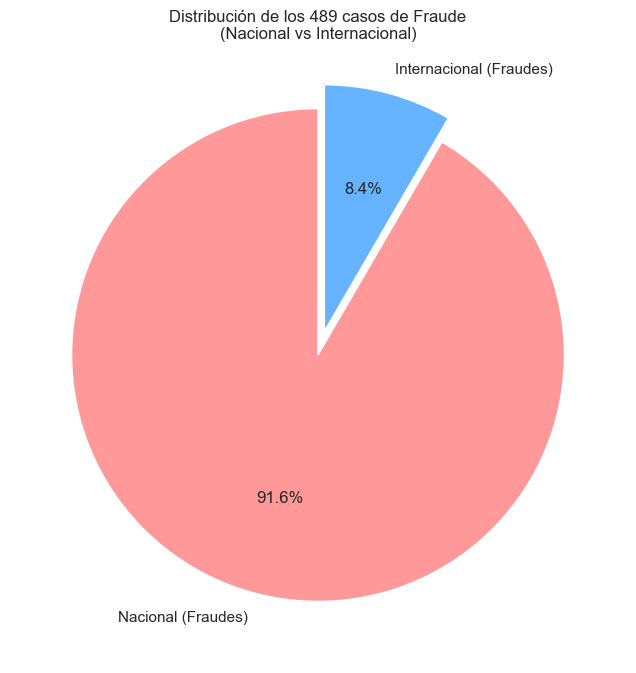

Cantidad exacta de fraudes:
Nacional (Fraudes)         448
Internacional (Fraudes)     41
dtype: int64


In [30]:
# Veamos si el fraude es más alto en transacciones internacionales
solo_fraude = df[df['fraud_label'] == 1]

# 2. Contamos cuántos hay por cada tipo (nacional vs internacional)
conteo_fraude_intl = solo_fraude.groupby('is_international').size()

# 3. Cambiamos los nombres de los índices para que el gráfico sea legible
conteo_fraude_intl.index = ['Nacional (Fraudes)', 'Internacional (Fraudes)']

# 4. Graficamos la proporción de ese "universo" de fraudes
plt.figure(figsize=(8, 8))
plt.pie(conteo_fraude_intl, 
        labels=conteo_fraude_intl.index, 
        autopct='%1.1f%%', 
        colors=['#ff9999','#66b3ff'], 
        startangle=90,
        explode=(0, 0.1))

plt.title('Distribución de los 489 casos de Fraude\n(Nacional vs Internacional)')
plt.show()


print("Cantidad exacta de fraudes:")
print(conteo_fraude_intl)

--- Análisis de Riesgo: Nacional vs Internacional ---


,Total Transacciones,% de Riesgo (Fraude)
Nacional (0),6745,6.641957
Internacional (1),755,5.430464


C:\Users\USER\AppData\Local\Temp\ipykernel_17420\1634564608.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tabla_riesgo.index, y='% de Riesgo (Fraude)', data=tabla_riesgo, palette='coolwarm')


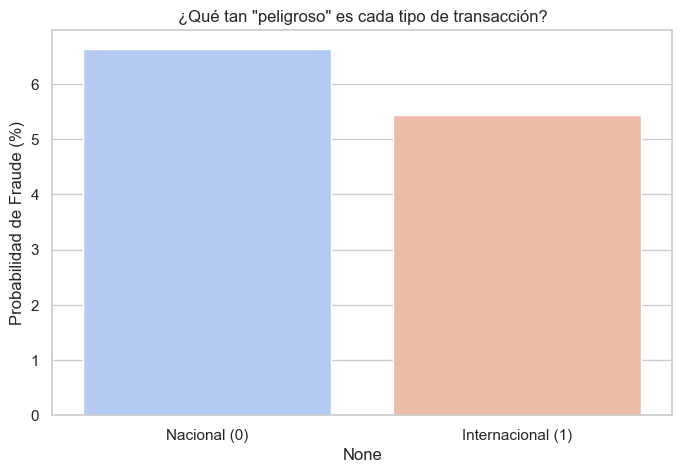

In [ ]:
# 1. Creamos una tabla de riesgo para saber cuantas transacciones por cada label hay y si las internacionales si son mas riesgosas
tabla_riesgo = df.groupby('is_international')['fraud_label'].agg(['count', 'mean'])

# 2. Formateo
tabla_riesgo['mean'] = tabla_riesgo['mean'] * 100
tabla_riesgo.columns = ['Total Transacciones', '% de Riesgo (Fraude)']
tabla_riesgo.index = ['Nacional (0)', 'Internacional (1)']

print("--- Análisis de Riesgo: Nacional vs Internacional ---")
display(tabla_riesgo)

# 3. Gráfico para comparar el riesgo directamente
plt.figure(figsize=(8, 5))
sns.barplot(x=tabla_riesgo.index, y='% de Riesgo (Fraude)', data=tabla_riesgo, palette='coolwarm')
plt.title('¿Qué tan "peligroso" es cada tipo de transacción?')
plt.ylabel('Probabilidad de Fraude (%)')
plt.show()

#### Conclusion
El dataset solo tiene ciudades de India, hay 2 ciudades donde el fraude es levemente superior al resto: Mumbai y Hyderabad.
Contrario a la creencia popular, las transacciones internacionales presentan un riesgo de fraude un 18% menor que las transacciones nacionales (5.43% frente a 6.64%). Esto sugiere que los mecanismos de seguridad para pagos extranjeros son efectivos o que el patrón de ataque está enfocado en el mercado interno de India principalmente en las dos ciudades anteriormente mencionadas.

### E. ¿Los intentos de login o la antiguedad de la cuenta se relacionan de forma positiva con el fraude?

Validaremos si el inteto de login y la antiguedad de la cuenta nos pueden brindar un patron para identificar las transacciones fraudulentas, haremos una agrupacion para ver el promedio de intentos de login entre las transacciones reales vs fraudulentas, adicional realizaremos un boxplot con una tabla para ver en comparativo de las transaciones  tanto de login  como antiguedad de las cuentas.

In [32]:
# Comparamos el promedio de intentos de login entre transacciones reales y fraude
intentos_login = df.groupby('fraud_label')['login_attempts_last_24h'].mean()
print("Promedio de intentos de login en las últimas 24h:")
print(intentos_login)

Promedio de intentos de login en las últimas 24h:
fraud_label
0    4.983882
1    5.155419
Name: login_attempts_last_24h, dtype: float64


In [71]:

# Asumiendo que tu DataFrame ya está cargado en la variable 'df'

# 1. Seleccionamos las dos variables que graficamos
columnas = ['login_attempts_last_24h', 'account_age_days']

# 2. Agrupamos por clase de fraude y sacamos las estadísticas
estadisticas = df.groupby('fraud_label')[columnas].describe()

# 3. Filtramos para mostrar solo los 5 valores que componen un Boxplot
# (Quitamos el conteo, el promedio y la desviación estándar)
valores_boxplot = estadisticas.loc[:, (slice(None), ['min', '25%', '50%', '75%', 'max'])]

# 4. Mostramos la tabla formateada (usamos 'display' que se ve mejor en Jupyter que 'print')
print("--- VALORES EXACTOS DE LAS CAJAS (BOXPLOTS) ---")
display(valores_boxplot)

--- VALORES EXACTOS DE LAS CAJAS (BOXPLOTS) ---


login_attempts_last_24h                     account_age_days  \
                                min  25%  50%  75%  max              min   
fraud_label                                                                
0                               1.0  3.0  5.0  7.0  9.0             10.0   
1                               1.0  3.0  5.0  7.0  9.0             10.0   

                                            
               25%     50%     75%     max  
fraud_label                                 
0            497.0  1012.0  1495.0  1999.0  
1            564.0  1108.0  1566.0  1996.0

C:\Users\ssaforozco\AppData\Local\Temp\ipykernel_6032\326732960.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='fraud_label', y='login_attempts_last_24h', palette='Set2')
C:\Users\ssaforozco\AppData\Local\Temp\ipykernel_6032\326732960.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df, x='fraud_label', y='account_age_days', palette='Set3')


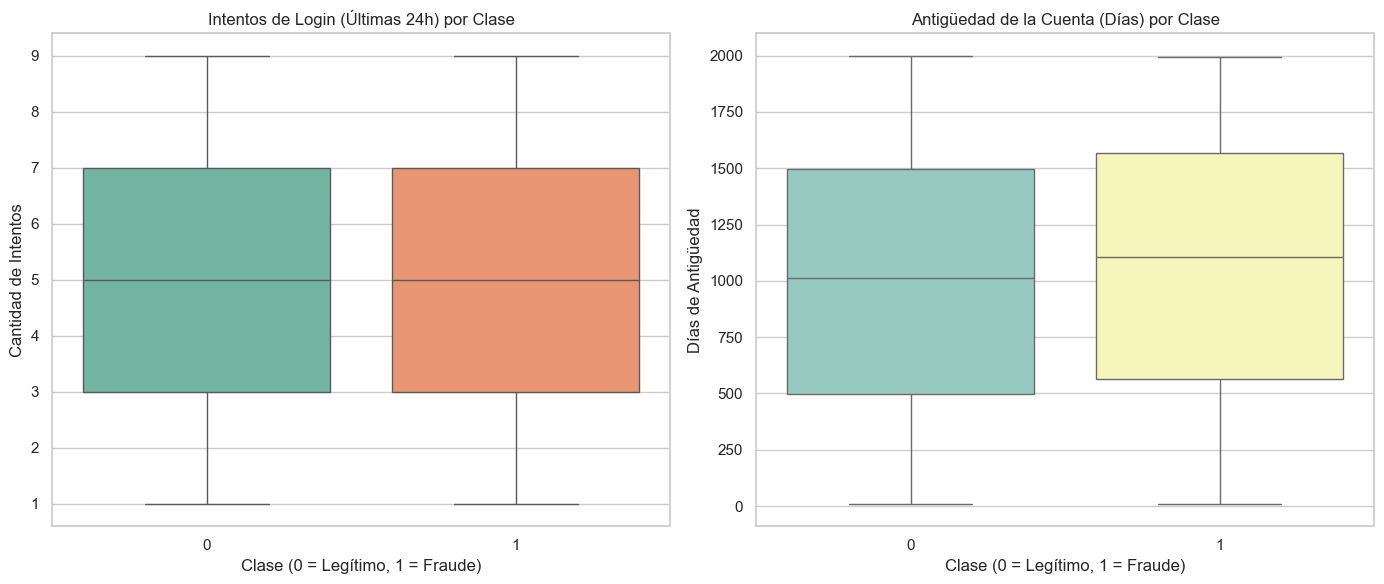

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Intentos de Login vs Fraude
sns.boxplot(ax=axes[0], data=df, x='fraud_label', y='login_attempts_last_24h', palette='Set2')
axes[0].set_title('Intentos de Login (Últimas 24h) por Clase')
axes[0].set_xlabel('Clase (0 = Legítimo, 1 = Fraude)')
axes[0].set_ylabel('Cantidad de Intentos')

# Gráfico 2: Antigüedad de la Cuenta vs Fraude
sns.boxplot(ax=axes[1], data=df, x='fraud_label', y='account_age_days', palette='Set3')
axes[1].set_title('Antigüedad de la Cuenta (Días) por Clase')
axes[1].set_xlabel('Clase (0 = Legítimo, 1 = Fraude)')
axes[1].set_ylabel('Días de Antigüedad')

plt.tight_layout()
plt.show()

#### Conclusion
Tenemos un promedio levemente mayor de intentos de login en fraude vs transacciones genuinas lo que quiere decir que un alto número de intentos de login en las últimas 24 horas no es un indicador determinante de fraude por sí solo, con Los mínimos y máximos de 1 a 9 intentos iguales en ambos grupos , en cuanto a la antiguedad se esperaría que el fraude viniera de cuentas nuevas creadas recientemente, pero los datos muestran que las cuentas donde hubo fraude tienen un promedio de 1071 días de antigüedad, mientras que las transacciones normales promedian los 1002 días no siendo un factor determinante por si solos el login o la antiguedad de la cuenta.

### F. ¿como se comporta la Correlacion de las Variables y su dispercion ?

En el ultimo Analisis que aplicaremos corresponde a una correlacion de las variables numericas para determinar como se comportan conforme a nuestra variable objetivo, por lo cual haremos un mapa de calor  y un grafico de las transaciones totales  vs el monto promedio.

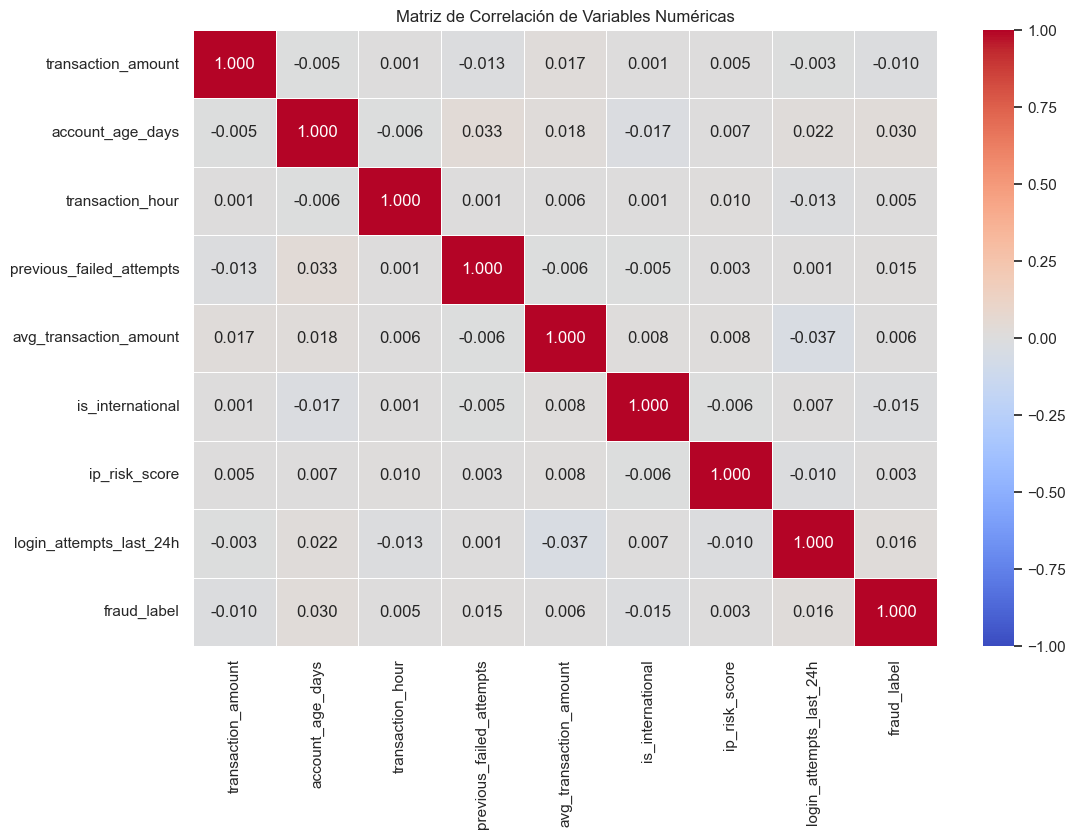

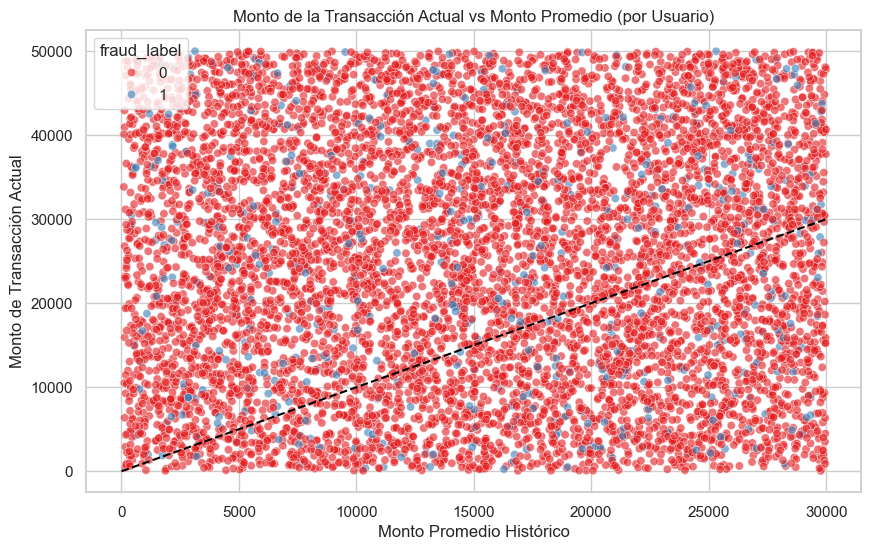

In [66]:
#1. Matriz de Correlación (Variables Numéricas)
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# 2. Análisis Multivariado: Relación Monto Actual vs Monto Promedio Histórico
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='avg_transaction_amount', y='transaction_amount', hue='fraud_label', alpha=0.6, palette='Set1')
plt.title('Monto de la Transacción Actual vs Monto Promedio (por Usuario)')
plt.xlabel('Monto Promedio Histórico')
plt.ylabel('Monto de Transacción Actual')
plt.plot([0, df['avg_transaction_amount'].max()], [0, df['avg_transaction_amount'].max()], color='black', linestyle='--') # Línea de ratio 1:1
plt.show()

#### Conclusion 
No hay correlaciones lineales fuertes entre las variables numéricas simples y el fraude.La correlación más "alta" es account_age_days (apenas un 0.029 positivo) como lo muestra el mapa de calor Y en el grafico de dispersion muestra que los fraudes están completamente mezclados con las transacciones genuinas sin un patron definido.

# 4.Feature Engineering (Ingeniería de Características)

Para mejorar el entendimiento para posibles modelos maching learning haremos que el dataset pase de tener 15 columnas a unas 28 columnas 100% numéricas , con el objetivo de proportcionar un insumo limpio al momento del Modelado, se creara variables compuestras de ratio de los montos  y del riesgo compuesto, adicional se eliminara columnas como Ids de transacion y usuario que sesgan el modelo , y se transformara las variables categoricas en agrupaciones que permitan la lectura a los modelos Machine learning de las variables.

In [ ]:
# Creamos una copia exacta del DataFrame original
# Asegúrate de que 'df' tenga el dataset original cargado previamente.
df_modelo = df.copy()

print("--- INICIANDO FEATURE ENGINEERING ---")
print(f"Tamaño original: {df_modelo.shape[1]} columnas")

# CREACIÓN DE VARIABLES NUMÉRICAS COMPUESTAS

# 1. Ratio del Monto: ¿Está gastando más de su promedio histórico? (Vital para detectar cambios bruscos)
df_modelo['ratio_monto_vs_promedio'] = df_modelo['transaction_amount'] / (df_modelo['avg_transaction_amount'] + 1)

# 2. Riesgo Compuesto: Cruza el riesgo de la IP con los intentos fallidos previos
df_modelo['riesgo_compuesto'] = df_modelo['ip_risk_score'] * (df_modelo['previous_failed_attempts'] + 1)

# CATEGORIZACIÓN (BINNING) DE VARIABLES CONTINUAS
# Antigüedad de la cuenta: Agrupamos los días en categorías lógicas para el negocio
# Tramos: Nueva (<30 días), Menos de 1 año, Entre 1 y 2 años, Veterana (>2 años)
df_modelo['categoria_antiguedad'] = pd.cut(
    df_modelo['account_age_days'], 
    bins=[-1, 30, 365, 730, np.inf], 
    labels=['Nueva_lt_30d', 'Menor_1_ano', '1_a_2_anos', 'Veterana_gt_2anos']
)

# Hora de la transacción: Convertimos la hora (0-23) en momentos del día
# Tramos: Madrugada (0-5), Mañana (6-11), Tarde (12-17), Noche (18-23)
df_modelo['momento_del_dia'] = pd.cut(
    df_modelo['transaction_hour'], 
    bins=[-1, 5, 11, 17, 23], 
    labels=['Madrugada', 'Manana', 'Tarde', 'Noche']
)

# LIMPIEZA DE COLUMNAS INNECESARIAS PARA MODELADO
# Eliminamos IDs porque no aportan patrones generalizables (solo causan sobreajuste / overfitting)
columnas_a_eliminar = ['transaction_id', 'user_id']
df_modelo = df_modelo.drop(columns=columnas_a_eliminar)


# CODIFICACIÓN DE VARIABLES CATEGÓRICAS 
# Los algoritmos matemáticos no entienden la palabra "Android" o "Transfer", necesitan 0s y 1s.
columnas_categoricas = [
    'transaction_type', 'payment_mode', 'device_type', 
    'device_location', 'categoria_antiguedad', 'momento_del_dia'
]

# get_dummies transforma estas categorías en nuevas columnas binarias.
# drop_first=True evita el problema de multicolinealidad (Dummy Variable Trap).
df_modelo = pd.get_dummies(df_modelo, columns=columnas_categoricas, drop_first=True)

# Convertir los valores booleanos (True/False) que arroja get_dummies a enteros (1/0)
# (Algunos modelos como XGBoost prefieren números estrictos)
df_modelo = df_modelo.astype(float)

# EXPORTAR Y GUARDAR EL DATASET FINAL
archivo_salida = 'Dataset_Preparado_Modelo.csv'
df_modelo.to_csv(archivo_salida, index=False)

print(f"Tamaño final tras Feature Engineering: {df_modelo.shape[1]} columnas")
print(f"¡Éxito! El dataset listo para modelar se guardó como: '{archivo_salida}'")
print("\nMuestra de las nuevas columnas listas para el modelo:")
print(df_modelo.columns.tolist())

--- INICIANDO FEATURE ENGINEERING ---
Tamaño original: 15 columnas
Tamaño final tras Feature Engineering: 28 columnas
¡Éxito! El dataset listo para modelar se guardó como: 'Dataset_Preparado_Modelo.csv'

Muestra de las nuevas columnas listas para el modelo:
['transaction_amount', 'account_age_days', 'transaction_hour', 'previous_failed_attempts', 'avg_transaction_amount', 'is_international', 'ip_risk_score', 'login_attempts_last_24h', 'fraud_label', 'ratio_monto_vs_promedio', 'riesgo_compuesto', 'transaction_type_Transfer', 'transaction_type_Withdrawal', 'payment_mode_NetBanking', 'payment_mode_UPI', 'payment_mode_Wallet', 'device_type_Web', 'device_type_iOS', 'device_location_Chennai', 'device_location_Delhi', 'device_location_Hyderabad', 'device_location_Mumbai', 'categoria_antiguedad_Menor_1_ano', 'categoria_antiguedad_1_a_2_anos', 'categoria_antiguedad_Veterana_gt_2anos', 'momento_del_dia_Manana', 'momento_del_dia_Tarde', 'momento_del_dia_Noche']


# 5.Conclusiones

Validamos matemáticamente un desbalance de clases ya que solo el 6.52% de las transacciones son anómalas. Adicionalmente, el análisis de correlación demostró una ausencia casi total de relaciones lineales fuertes frente a la variable objetivo, lo que indica que el fraude opera bajo lógicas condicionales complejas y descarta el uso de modelos paramétricos simples como la Regresión Logística.
Como ninguna variable por sí sola detecta el fraude, tuvimos que crear nuevas métricas combinadas (Feature Engineering). Descubrimos que el fraude salta a la vista cuando cruzamos datos; por ejemplo, evaluar si el usuario está gastando mucho más de su promedio histórico usando una IP riesgosa, Dado que el fraude aquí es un rompecabezas de combinaciones complejas, los modelos simples no servirán,se puede tener alertas en ciertas ciudades o localizaciones conforme al analisis.

Investigando vemos que la mejor opcion en estos casos es basarse en modelo de Árboles que son expertos en cruzar variables. Además, a seria necesario aplicar técnicas de balanceo de datos para obligar al algoritmo a prestarle atención a ese pequeño 6.5% de transacciones fraudulentas.